In [1]:
import os
import anndata as ad
import pandas as pd
import numpy as np
import torch
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import random

In [2]:
adata = ad.read_h5ad('merged.h5ad')

In [3]:
# ===== Load Latent Embeddings from AnnData =====
z_all = torch.tensor(adata.obsm["ExPert_latent_z_shared"], dtype=torch.float32)
pert_labels, uniques = pd.factorize(adata.obs['perturbation'])
y_all_tensor = torch.tensor(pert_labels, dtype=torch.long)

In [4]:
os.makedirs("splits", exist_ok=True)

In [5]:
# Allocate query/control cells into the dataset-specific splits before exporting.
# Each dataset's controls follow that dataset's observed non-query split proportions.
SPLIT_SEED = 42
rng = np.random.default_rng(SPLIT_SEED)

split_for_export = adata.obs["split"].astype(str).copy()
query_control_mask = (split_for_export == "query") & (adata.obs["perturbation"].astype(str) == "control")
control_allocation_records = []

for dataset, dataset_idx in adata.obs.groupby("dataset", observed=True).groups.items():
    dataset_idx = np.asarray(dataset_idx)
    dataset_query_controls = dataset_idx[query_control_mask.loc[dataset_idx].to_numpy()]
    if len(dataset_query_controls) == 0:
        continue

    reference_splits = split_for_export.loc[dataset_idx[~query_control_mask.loc[dataset_idx].to_numpy()]]
    split_counts = reference_splits[reference_splits != "query"].value_counts()
    split_counts = split_counts.reindex(["train", "val", "test", "ood_test"], fill_value=0)

    if split_counts.sum() == 0:
        raise ValueError(f"No non-query rows available to allocate controls for dataset {dataset!r}")

    expected = len(dataset_query_controls) * split_counts / split_counts.sum()
    target_counts = np.floor(expected).astype(int)
    remainder = int(len(dataset_query_controls) - target_counts.sum())
    if remainder:
        order = (expected - target_counts).sort_values(ascending=False).index[:remainder]
        target_counts.loc[order] += 1

    shuffled_controls = rng.permutation(dataset_query_controls)
    start = 0
    for split_name, count in target_counts.items():
        count = int(count)
        if count == 0:
            continue
        chosen = shuffled_controls[start:start + count]
        split_for_export.loc[chosen] = split_name
        control_allocation_records.append({
            "dataset": dataset,
            "split": split_name,
            "n_controls": count,
        })
        start += count

control_allocation_summary = pd.DataFrame(control_allocation_records)
if not control_allocation_summary.empty:
    control_allocation_summary = control_allocation_summary.pivot_table(
        index="dataset",
        columns="split",
        values="n_controls",
        fill_value=0,
        aggfunc="sum",
    ).reindex(columns=["train", "val", "test", "ood_test"], fill_value=0)

effective_split = split_for_export
print(effective_split.value_counts().reindex(["train", "val", "test", "ood_test", "query"], fill_value=0))
control_allocation_summary


split
train       154240
val           8570
test          8567
ood_test     25872
query            0
Name: count, dtype: int64


split,train,val,test,ood_test
dataset,,,,
Marson2025_D1_Rest,901,49,50,0
Marson2025_D1_Stim48hr,0,0,0,1000
Marson2025_D1_Stim8hr,900,51,49,0
Marson2025_D2_Rest,900,51,49,0
Marson2025_D2_Stim48hr,900,50,50,0
Marson2025_D2_Stim8hr,900,50,50,0
Marson2025_D3_Rest,900,50,50,0
Marson2025_D3_Stim48hr,900,50,50,0
Marson2025_D3_Stim8hr,900,50,50,0


### Train / Valid / Test split

In [6]:
train_mask = effective_split == "train"
val_mask   = effective_split == "val"
test_mask  = effective_split == "test"
ood_mask = effective_split == "ood_test"


In [7]:
z_train = z_all[train_mask.values]
z_val   = z_all[val_mask.values]
z_test  = z_all[test_mask.values]
z_ood = z_all[ood_mask.values]

y_train = y_all_tensor[train_mask.values]
y_val   = y_all_tensor[val_mask.values]
y_test  = y_all_tensor[test_mask.values]
y_ood = y_all_tensor[ood_mask.values]

In [8]:
np.save('splits/z_train.npy', z_train.cpu().numpy())
np.save('splits/z_val.npy',   z_val.cpu().numpy())
np.save('splits/z_test.npy',  z_test.cpu().numpy())
np.save('splits/z_ood.npy',  z_ood.cpu().numpy())

np.save('splits/y_train.npy', y_train.cpu().numpy())
np.save('splits/y_val.npy',   y_val.cpu().numpy())
np.save('splits/y_test.npy',  y_test.cpu().numpy())
np.save('splits/y_ood.npy',  y_ood.cpu().numpy())

np.save("splits/perturbation_names.npy", uniques)
np.save("splits/effective_split.npy", effective_split.to_numpy())
control_allocation_summary.to_csv("splits/control_allocation_summary.csv")


### Plot test embedding

In [9]:
# visualize original data
seed = 42 # change if needed 

np.random.seed(seed)
random.seed(seed)

/projects/b1042/GoyalLab/jaekj/python/KS_perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/projects/b1042/GoyalLab/jaekj/python/KS_perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


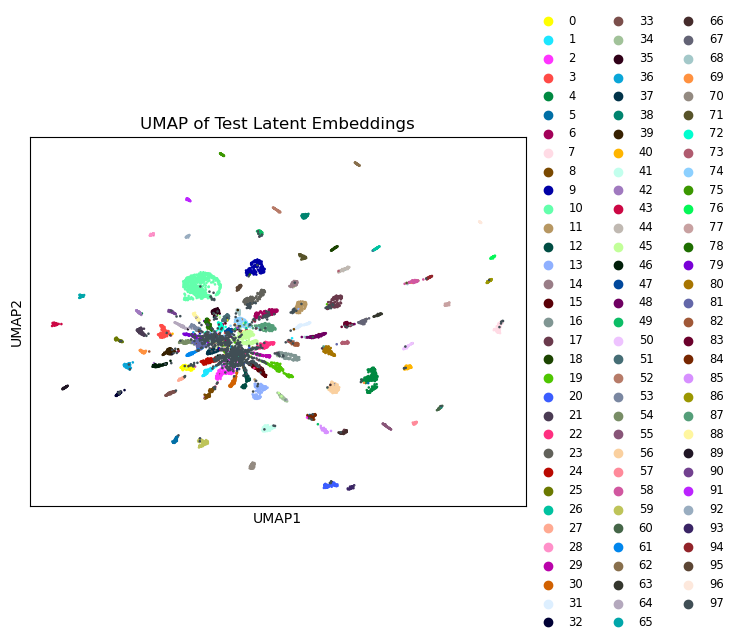

In [10]:
# -------------------------
# Load saved test data
# -------------------------
z_test = np.load("splits/z_test.npy")
y_test = np.load("splits/y_test.npy")

# Convert labels to strings for plotting
y_test = y_test.astype(str)

# -------------------------
# Build AnnData
# -------------------------
adata_test = ad.AnnData(
    X=z_test,
    obs=pd.DataFrame({"perturbation": y_test})
)

# -------------------------
# Compute neighbors + UMAP
# (no PCA because X = z_test latent)
# -------------------------
sc.pp.neighbors(adata_test, use_rep="X", n_neighbors=15)
sc.tl.umap(adata_test, random_state = seed) 

# -------------------------
# Plot UMAP
# -------------------------
sc.pl.umap(
    adata_test,
    color="perturbation",
    legend_fontsize="small",
    title="UMAP of Test Latent Embeddings",
    show=True
)

In [11]:
pert_names = np.load("splits/perturbation_names.npy", allow_pickle=True)

In [12]:
y_test

array(['0', '2', '15', ..., '97', '97', '97'], dtype='<U21')

In [13]:
adata_test.obs["pert_name"] = pert_names[y_test.astype(int)]

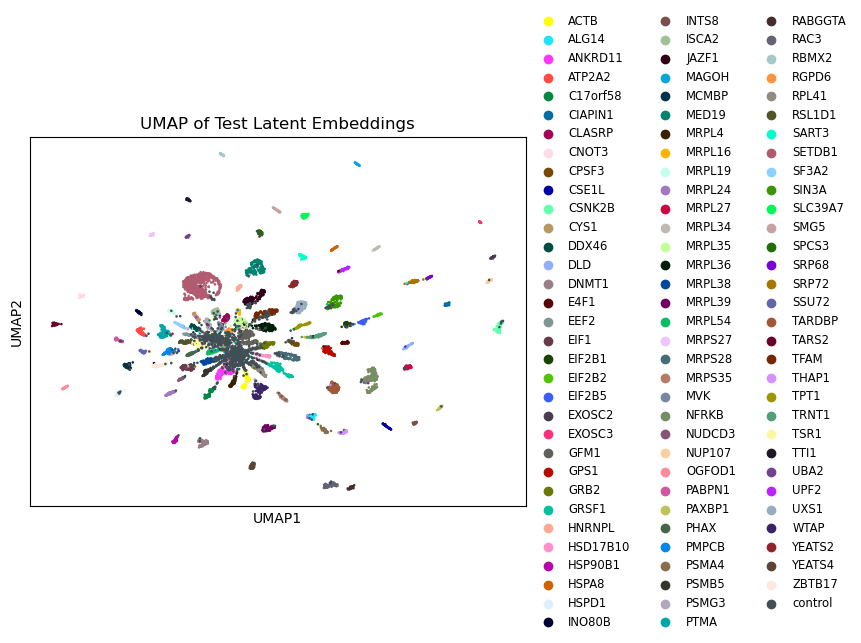

In [14]:
ax = sc.pl.umap(
    adata_test,
    color="pert_name",
    legend_fontsize="small",
    title="UMAP of Test Latent Embeddings",
    show=False
)

In [15]:
fig = ax.figure   # <-- get the Figure from the Axes

fig.savefig("figures/umap_test.png", dpi=150, bbox_inches="tight")
fig.savefig("figures/umap_test.svg", dpi=150, bbox_inches="tight")
plt.close(fig)

### OOD data

/projects/b1042/GoyalLab/jaekj/python/KS_perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


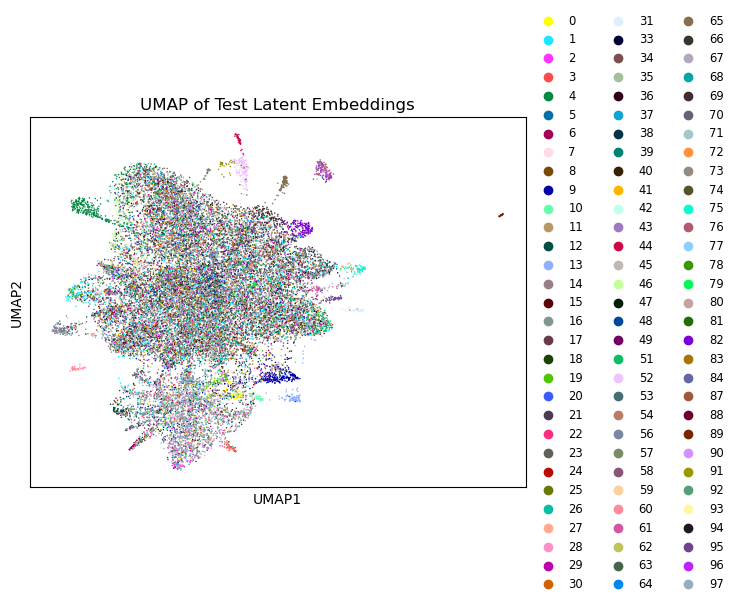

In [16]:
# -------------------------
# Load saved test data
# -------------------------
z_ood = np.load("splits/z_ood.npy")
y_ood = np.load("splits/y_ood.npy")

# Convert labels to strings for plotting
y_ood = y_ood.astype(str)

# -------------------------
# Build AnnData
# -------------------------
adata_ood = ad.AnnData(
    X=z_ood,
    obs=pd.DataFrame({"perturbation": y_ood})
)

# -------------------------
# Compute neighbors + UMAP
# (no PCA because X = z_test latent)
# -------------------------
sc.pp.neighbors(adata_ood, use_rep="X", n_neighbors=15)
sc.tl.umap(adata_ood, random_state = seed) 

# -------------------------
# Plot UMAP
# -------------------------
sc.pl.umap(
    adata_ood,
    color="perturbation",
    legend_fontsize="small",
    title="UMAP of Test Latent Embeddings",
    show=True
)

In [17]:
adata_ood.obs["pert_name"] = pert_names[y_ood.astype(int)]

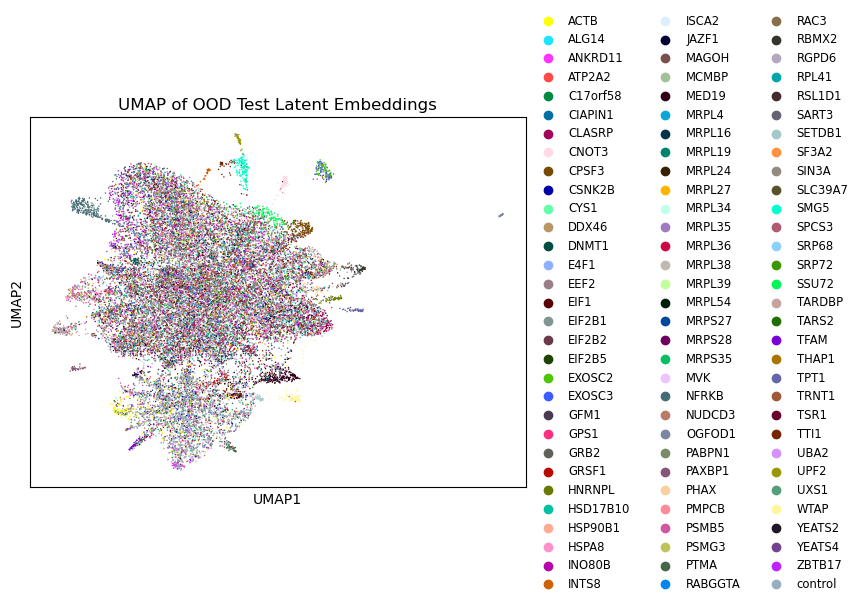

In [18]:
ax = sc.pl.umap(
    adata_ood,
    color="pert_name",
    legend_fontsize="small",
    title="UMAP of OOD Test Latent Embeddings",
    show=False
)

In [19]:
fig = ax.figure   # <-- get the Figure from the Axes

fig.savefig("figures/umap_ood.png", dpi=150, bbox_inches="tight")
fig.savefig("figures/umap_ood.svg", dpi=150, bbox_inches="tight")
plt.close(fig)